### 1. Завантаження та підготовка даних

Завантажимо набір даних

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Виведемо перші п'ять рядків і статистики колонок

In [96]:
df_original = pd.read_csv("spotify/SpotifyFeatures.csv")
df_from_csv = df_original.copy()
print(df_from_csv.head(5))

   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       137373   0.737             0.000  F#

In [97]:
print(f"\nOriginal statistics:")
print(df_from_csv.describe())


Original statistics:
          popularity   acousticness   danceability   duration_ms  \
count  232725.000000  232725.000000  232725.000000  2.327250e+05   
mean       41.127502       0.368560       0.554364  2.351223e+05   
std        18.189948       0.354768       0.185608  1.189359e+05   
min         0.000000       0.000000       0.056900  1.538700e+04   
25%        29.000000       0.037600       0.435000  1.828570e+05   
50%        43.000000       0.232000       0.571000  2.204270e+05   
75%        55.000000       0.722000       0.692000  2.657680e+05   
max       100.000000       0.996000       0.989000  5.552917e+06   

              energy  instrumentalness       liveness       loudness  \
count  232725.000000     232725.000000  232725.000000  232725.000000   
mean        0.570958          0.148301       0.215009      -9.569885   
std         0.263456          0.302768       0.198273       5.998204   
min         0.000020          0.000000       0.009670     -52.457000   
25%  

Для зменшення кількості точок у візуалізації залишимо лише треки з popularity ≥ 85. (Решту треків можна використати для навчання моделі, але візуалізувати лише популярні.)

In [98]:
high_popularity = df_original[df_original['popularity'] >= 85].copy()
print(high_popularity.head(5))

      genre    artist_name                                track_name  \
9026  Dance  Ariana Grande  break up with your girlfriend, i'm bored   
9027  Dance  Ariana Grande                                   7 rings   
9028  Dance         Halsey                                Without Me   
9029  Dance  Ariana Grande                                     needy   
9030  Dance  Ariana Grande                                      NASA   

                    track_id  popularity  acousticness  danceability  \
9026  4kV4N9D1iKVxx1KLvtTpjS          99        0.0421         0.726   
9027  14msK75pk3pA33pzPVNtBF         100        0.5780         0.725   
9028  5p7ujcrUXASCNwRaWNHR1C          97        0.2970         0.752   
9029  1TEL6MlSSVLSdhOSddidlJ          92        0.7800         0.647   
9030  4uTvPEr01pjTbZgl7jcKBD          91        0.4510         0.747   

      duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
9026       190440   0.554          0.000000   F    0.106

Виконаємо стандартизацію числових ознак

In [99]:
num_cols = df_from_csv.select_dtypes(include=['number']).columns
print(num_cols)


Index(['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence'],
      dtype='str')


In [100]:
scaler_std = StandardScaler()
df_from_csv[num_cols] = scaler_std.fit_transform(df_from_csv[num_cols])

print("Standardized data:")
print(df_from_csv.head(5))

Standardized data:
   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV   -2.261007      0.683376     -0.890935   
1  0BjC1NfoEOOusryehmNudP   -2.206031     -0.345467      0.191994   
2  0CoSDzoNIKCRs124s9uTVy   -2.096080      1.644570      0.585296   
3  0Gc6TVm52BwZD07Ki6tIvf   -2.261007      0.942701     -1.693703   
4  0IuslXpMROHdEPvSl1fTQK   -2.041104      1.638932     -1.203422   

   duration_ms    energy  instrumentalness key  liveness  loudness   mode  \
0    -1.141368  1.286908         -0.489819  C#  0.660661  1.290703  Major   
1    -0.821867  0.630

Виведемо розмірність таблиці після фільтрації

In [102]:
high_popularity.shape

(417, 18)

### Підберемо оптимальну кількусть кластерів (k) — метод ліктя

1. Ініціалізуалізуємо модель KMeans із різною кількістю кластерів (наприклад k = 2…15)
2. Для кожного k обчислити інерцію (суму квадратів відстаней до центрів кластерів).
3. Побудувати графік залежності інерції від k.
4. Визначити оптимальне k.

In [103]:
from sklearn.cluster import KMeans
def find_optimal_k(X, max_k):
    k_range = range(2, max_k + 1)

    wcss_values = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        wcss_values.append(kmeans.inertia_)

    return {
        'k_range': list(k_range),
        'wcss': wcss_values
            }


In [104]:
optimal_results = find_optimal_k(df_from_csv[num_cols], 15)

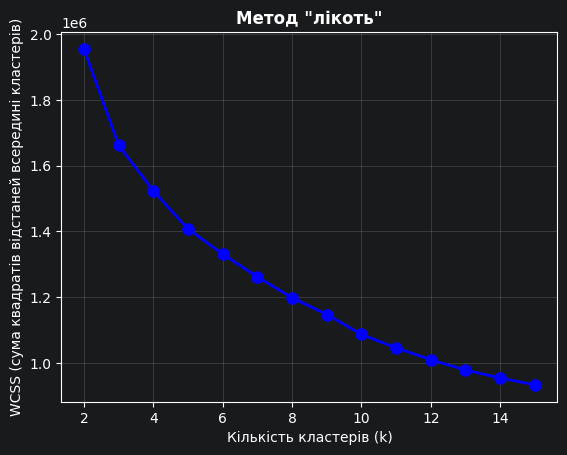

In [105]:
fig, ax = plt.subplots()
ax.plot(optimal_results['k_range'], optimal_results['wcss'],'bo-', linewidth=2, markersize=8)

ax.set_xlabel('Кількість кластерів (k)')
ax.set_ylabel('WCSS (сума квадратів відстаней всередині кластерів)')
ax.set_title('Метод "лікоть"', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.show()

##### Отже, оптимальне значення k це 6

### Побудова кластеризації

1. Виконаємо кластеризацію з обраним значенням k.
2. Додамо отримані мітки кластерів до DataFrame як нову колонку cluster.
3. Виведемо кількість треків у кожному кластері.


In [106]:
def kmeans_analysis(X, k):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_

    wcss = kmeans.inertia_

    print(f"Результати кластеризації:")
    print(f"   • WCSS (інерція): {wcss:.2f}")

    unique, counts = np.unique(cluster_labels, return_counts=True)
    print(f"   • Розміри кластерів: {dict(zip(unique, counts))}")

    return {
        'kmeans': kmeans,
        'labels': cluster_labels,
        'centroids': centroids,
        'wcss': wcss
    }

In [107]:
results = kmeans_analysis(df_from_csv[num_cols], 6)

Результати кластеризації:
   • WCSS (інерція): 1331154.06
   • Розміри кластерів: {np.int32(0): np.int64(46742), np.int32(1): np.int64(59661), np.int32(2): np.int64(57403), np.int32(3): np.int64(10060), np.int32(4): np.int64(32907), np.int32(5): np.int64(25952)}


In [111]:
df_original['cluster'] = results['labels']

In [112]:
print(df_original.head(5))

   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       137373   0.737             0.000  F#

### Візуалізація кластерів у просторі головних компонент

Виконаємо PCA до двох/трьох компонент для візуалізації.

Побудуємо 2D/3D-графік з кольором точок за значенням cluster. Для покращення читабельності візуалізувати лише треки з popularity ≥ 85.


In [118]:
from sklearn.decomposition import PCA
import plotly.express as px
n_components = 2
pca = PCA(n_components=n_components)
components = pca.fit_transform(df_from_csv[num_cols])

mask = df_original['popularity'] >= 85

fig = px.scatter(
    components[mask],
    x=0,
    y=1,
    color=df_original.loc[mask, 'cluster'].astype(str)
)

fig.show()


### Аналіз кластерів

* Для кожного кластера обчислимо статистики основних ознак.
* Побудуємо таблицю середніх значень основних ознак або графік (heatmap).


In [119]:
df_original.groupby('cluster')[num_cols].agg(['mean','std','min','max'])

popularity                     acousticness                      \
              mean        std min  max         mean       std       min   
cluster                                                                   
0        41.804608  15.093994   0   93     0.103581  0.161683  0.000001   
1        55.110307  11.699957   0  100     0.206629  0.214796  0.000000   
2        41.031706  17.107271   0   97     0.219068  0.224837  0.000002   
3        20.740060  10.035117   0   66     0.794045  0.129287  0.000598   
4        30.334488  19.335365   0   80     0.808878  0.177339  0.000233   
5        29.563271  13.741378   0   75     0.825484  0.237424  0.000001   

               danceability            ... speechiness              tempo  \
           max         mean       std  ...         min    max        mean   
cluster                                ...                                  
0        0.980     0.481497  0.125916  ...      0.0238  0.880  150.720646   
1        0.965     0.622095  0.136189  ...      0.0222  0.820  108.842940   
2        0.996     0.710927  0.108783  ...      0.0223  0.817  113.420508   
3        0.995     0.562684  0.090820  ...      0.1430  0.967   97.916415   
4        0.996     0.457148  0.158543  ...      0.0224  0.792  111.336466   
5        0.996     0.303645  0.165229  ...      0.0228  0.798  103.492111   

                                      valence                           
               std     min      max      mean       std     min    max  
cluster                                                                 
0        25.423039  61.948  242.903  0.472897  0.208972  0.0000  0.989  
1        22.797255  36.542  205.888  0.357960  0.154860  0.0241  0.813  
2        23.346824  46.483  209.970  0.756203  0.133697  0.1390  1.000  
3        27.691616  32.244  216.312  0.414072  0.204960  0.0000  0.979  
4        30.119282  32.509  236.735  0.320156  0.207770  0.0000  1.000  
5        30.985864  30.379  220.119  0.165724  0.178579  0.0000  1.000  

[6 rows x 44 columns]

In [129]:
cluster_stats = df_original.groupby('cluster')[num_cols].mean()
print(cluster_stats)

         popularity  acousticness  danceability    duration_ms    energy  \
cluster                                                                    
0         41.804608      0.103581      0.481497  243355.542360  0.790053   
1         55.110307      0.206629      0.622095  236150.524966  0.607784   
2         41.031706      0.219068      0.710927  219310.933645  0.690268   
3         20.740060      0.794045      0.562684  245029.028429  0.663335   
4         30.334488      0.808878      0.457148  224363.347343  0.263431   
5         29.563271      0.825484      0.303645  262705.108007  0.181918   

         instrumentalness  liveness   loudness  speechiness       tempo  \
cluster                                                                   
0                0.094759  0.271546  -5.806455     0.098252  150.720646   
1                0.057175  0.163351  -7.283025     0.098743  108.842940   
2                0.069670  0.178896  -7.146485     0.097827  113.420508   
3               

In [130]:
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_stats)

cluster_stats_scaled = pd.DataFrame(
    scaled,
    index=cluster_stats.index,
    columns=cluster_stats.columns
)


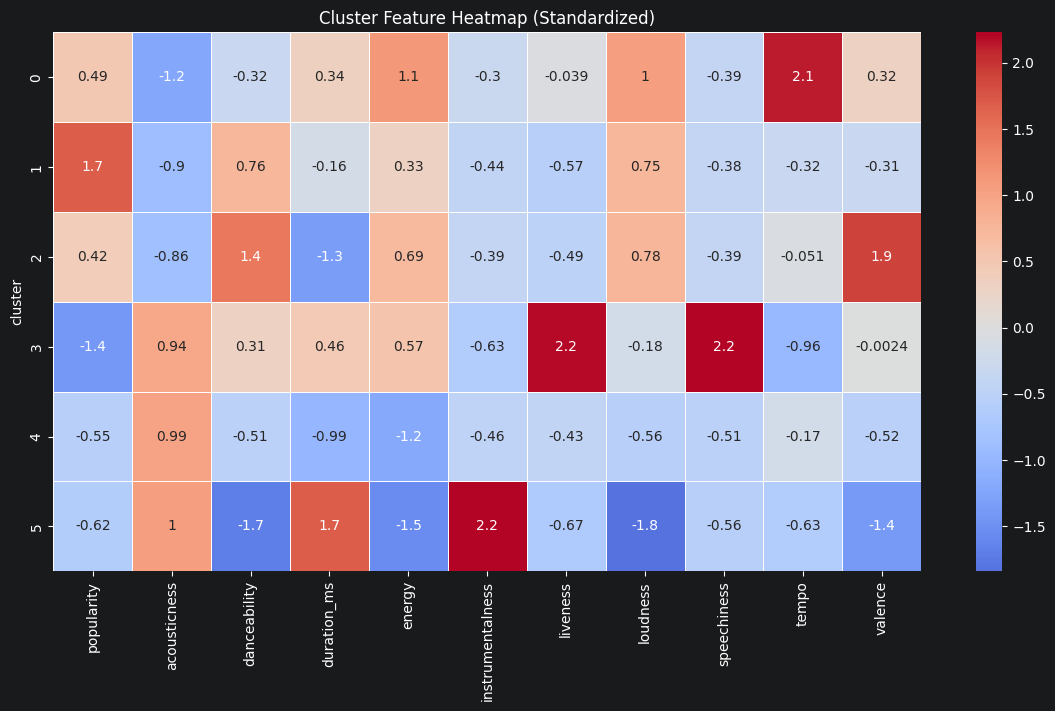

In [132]:
import seaborn as sns
plt.figure(figsize=(14,7))

sns.heatmap(
    cluster_stats_scaled,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Cluster Feature Heatmap (Standardized)")
plt.show()